In [3]:
import os
from os.path import join as opj

import numpy as np
from omegaconf import OmegaConf
from copy import deepcopy
import torch
from datetime import datetime
from matplotlib import pyplot as plt

from utils.gumbel_softmax import gumbel_softmax
from utils.misc import reproduc, plot_causal_matrix, plot_causal_matrix_in_training, calc_and_log_metrics
from utils.logger import MyLogger

from data.simu_data import simulate_var, simulate_random_var, load_dream_data, simulate_lorenz_96

import cuts_plus

In [4]:
import numpy as np
import pandas as pd
from datetime import datetime

# 设置参数
processed_folder = 'data/price/processed'
start_date = '2014-11-20'

# 方法1：从CSV加载（推荐，更直观）
def load_from_csv():
    # 加载CSV文件
    df = pd.read_csv(f'{processed_folder}/aligned_adj_close.csv',
                     index_col=0,
                     parse_dates=True)

    # 筛选2014年11月20日之后的数据
    df_filtered = df[df.index >= start_date]

    # 转换为NumPy数组
    data_array = df_filtered.values

    # 获取股票列表和日期列表（可选，供参考）
    stock_list = df_filtered.columns.tolist()
    date_list = df_filtered.index.tolist()

    return data_array, stock_list, date_list

# 方法2：从NPY加载
def load_from_npy():
    # 加载NumPy数组和元数据
    data_array = np.load(f'{processed_folder}/aligned_adj_close.npy')
    metadata = np.load(f'{processed_folder}/aligned_metadata.npy', allow_pickle=True).item()

    # 将日期字符串转换为datetime对象
    dates = pd.to_datetime(metadata['dates'])

    # 找到起始日期的索引
    start_idx = np.where(dates >= pd.to_datetime(start_date))[0]

    if len(start_idx) == 0:
        print(f"警告：没有找到{start_date}之后的数据")
        return None, None, None

    # 切片获取所需数据
    data_array_filtered = data_array[start_idx[0]:, :]
    stock_list = metadata['stocks']
    date_list = dates[start_idx[0]:].tolist()

    return data_array_filtered, stock_list, date_list

# 主加载函数（推荐使用）
def load_stock_data_after_date(start_date='2014-11-20', method='csv'):
    """
    加载指定日期之后的股票数据

    Parameters:
    start_date: 起始日期，格式 'YYYY-MM-DD'
    method: 'csv' 或 'npy'，选择加载方式

    Returns:
    data: NumPy数组，shape为(时间步, 股票数量)
    stocks: 股票代码列表
    dates: 日期列表
    """
    if method == 'csv':
        data, stocks, dates = load_from_csv()
    else:
        data, stocks, dates = load_from_npy()

    if data is not None:
        print(f"数据加载成功！")
        print(f"- 数据形状: {data.shape}")
        print(f"- 时间范围: {dates[0].strftime('%Y-%m-%d')} 到 {dates[-1].strftime('%Y-%m-%d')}")
        print(f"- 股票数量: {len(stocks)}")
        print(f"- 股票列表: {stocks[:5]}...（显示前5个）")

        # 显示缺失值信息
        nan_count = np.isnan(data).sum()
        total_count = data.size
        print(f"- 缺失值: {nan_count} ({nan_count/total_count*100:.2f}%)")

    return data, stocks, dates

# ===== 执行加载 =====
# 使用CSV方法加载（推荐）
data, stocks, dates = load_stock_data_after_date(start_date='2014-11-20', method='csv')

# 如果只需要纯NumPy数组，直接使用data变量
print(f"data形状: {data.shape}")



数据加载成功！
- 数据形状: (701, 88)
- 时间范围: 2014-11-20 到 2017-09-01
- 股票数量: 88
- 股票列表: ['AAPL', 'ABB', 'ABBV', 'AEP', 'AGFS']...（显示前5个）
- 缺失值: 407 (0.66%)
data形状: (701, 88)


# 运行CUTS+

使用设备: cuda
数据形状: (701, 88)
时间步数: 701
股票数量: 88
数据缺失率: 0.66%


/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:147: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.

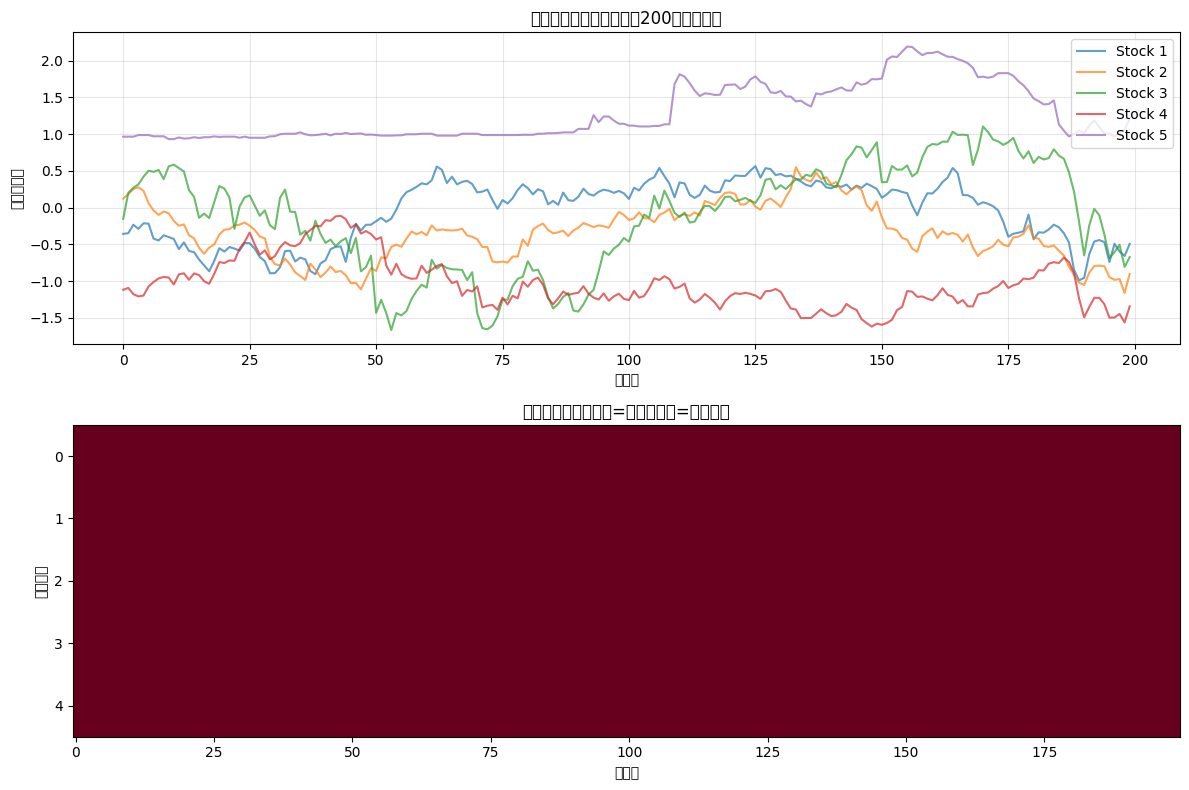


开始运行CUTS+算法...
配置参数:
- 输入步数: 5
- 预测步数: 1
- 训练轮数: 100
- 批次大小: 128
n_groups:  32
Using masked supervision for data prediction (masked_before_100)......


 20%|██        | 20/100 [00:49<03:12,  2.40s/it, S2 loss=0.05, spr=0.61, auc=0.0000]

Data update started!


100%|██████████| 100/100 [04:27<00:00,  2.67s/it, S2 loss=0.03, spr=0.58, auc=0.0000]



生成的因果图:


/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_10260/1401541452.py:191: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from current font.

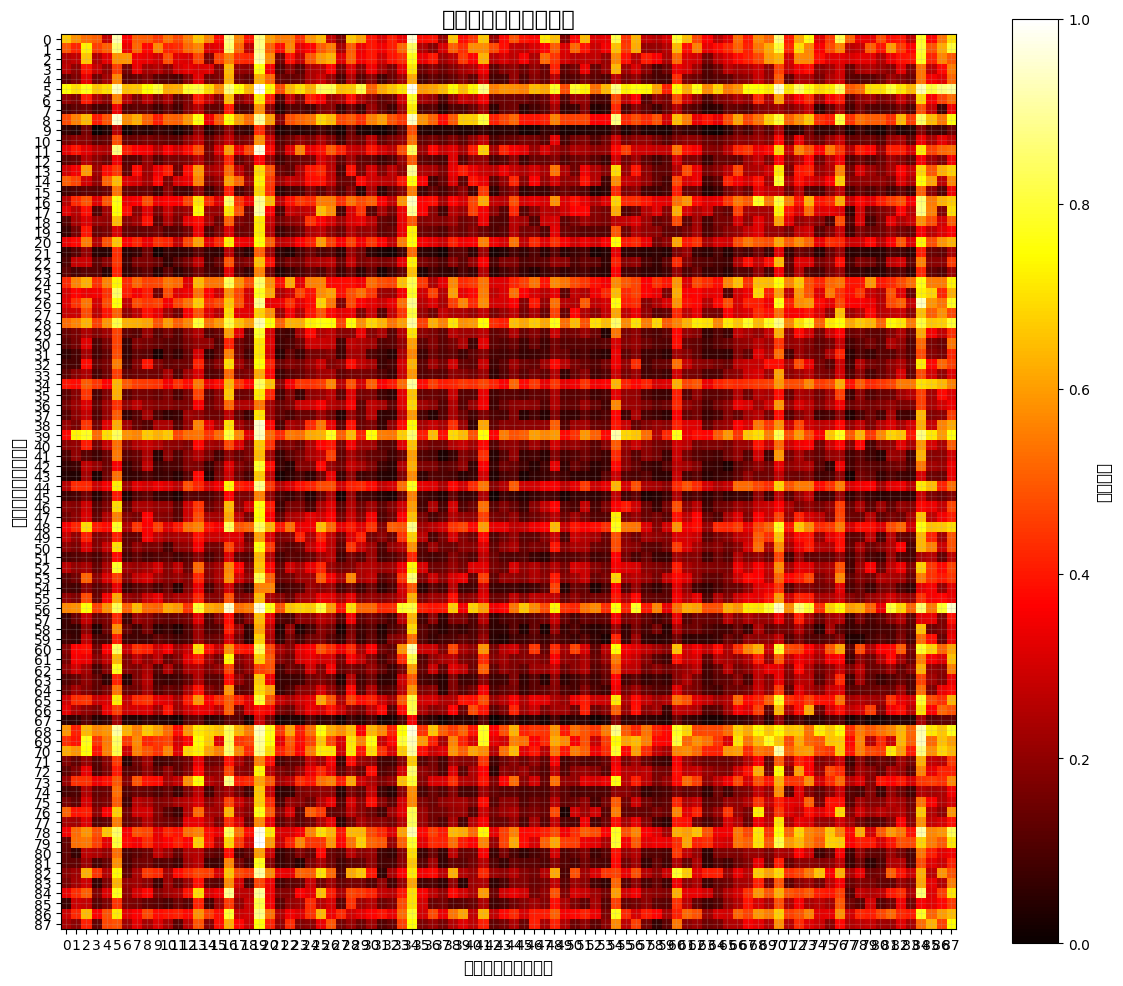


强因果关系（阈值>0.5）:
股票1 → 股票2: 强度=0.583
股票1 → 股票3: 强度=0.528
股票1 → 股票4: 强度=0.510
股票1 → 股票6: 强度=0.920
股票1 → 股票8: 强度=0.505
股票1 → 股票9: 强度=0.502
股票1 → 股票11: 强度=0.537
股票1 → 股票13: 强度=0.553
股票1 → 股票14: 强度=0.661
股票1 → 股票15: 强度=0.564
股票1 → 股票17: 强度=0.881
股票1 → 股票18: 强度=0.563
股票1 → 股票20: 强度=0.872
股票1 → 股票21: 强度=0.601
股票1 → 股票22: 强度=0.550
股票1 → 股票23: 强度=0.554
股票1 → 股票25: 强度=0.589
股票1 → 股票26: 强度=0.644
股票1 → 股票29: 强度=0.667
股票1 → 股票30: 强度=0.607
股票1 → 股票35: 强度=0.955
股票1 → 股票39: 强度=0.660
股票1 → 股票42: 强度=0.664
股票1 → 股票48: 强度=0.712
股票1 → 股票49: 强度=0.652
股票1 → 股票52: 强度=0.642
股票1 → 股票55: 强度=0.816
股票1 → 股票57: 强度=0.635
股票1 → 股票61: 强度=0.790
股票1 → 股票62: 强度=0.649
股票1 → 股票67: 强度=0.525
股票1 → 股票69: 强度=0.567
股票1 → 股票70: 强度=0.513
股票1 → 股票71: 强度=0.867
股票1 → 股票73: 强度=0.616
股票1 → 股票74: 强度=0.760
股票1 → 股票77: 强度=0.825
股票1 → 股票78: 强度=0.513
股票1 → 股票85: 强度=0.779
股票1 → 股票87: 强度=0.539
股票1 → 股票88: 强度=0.700
股票2 → 股票3: 强度=0.726
股票2 → 股票5: 强度=0.511
股票2 → 股票6: 强度=0.856
股票2 → 股票8: 强度=0.519
股票2 → 股票10: 强度=0.566
股票2 → 股票13: 强度=0.523
股票2 → 股

In [5]:

from os.path import join as opj
import numpy as np
from omegaconf import OmegaConf
import torch
from datetime import datetime
from matplotlib import pyplot as plt

from utils.misc import reproduc, plot_causal_matrix
from utils.logger import MyLogger

import cuts_plus
# 创建配置
config = {
    'dir_name': 'outputs',
    'task_name': 'stock_causal_discovery',

    'log': {
        'stdout': False,
        'stderr': False,
        'tensorboard': True
    },

    'reproduc': {
        'seed': 42,
        'benchmark': False,
        'deterministic': True
    },

    'data': {
        'missing': {
            'p_noise': 0.0,  # 如果数据已经有缺失值，设为0
            'p_block': 0.0,  # 如果不需要额外添加块缺失，设为0
            'max_seq': 48,
            'min_seq': 12
        }
    },

    'sota': {
        'cuts_plus': {
            'n_nodes': 'auto',  # 自动检测节点数（股票数）
            'input_step': 5,    # 使用过去5个时间步来预测，可以调整
            'batch_size': 128,
            'data_dim': 1,
            'total_epoch': 100,  # 训练轮数，可根据需要调整

            'n_groups': 32,
            'group_policy': 'multiply_2_every_20',

            'supervision_policy': 'masked_before_100',
            'fill_policy': 'rate_0.1_after_20',
            'show_graph_every': 20,  # 每20轮显示一次因果图

            'data_pred': {
                'model': 'multi_lstm',
                'pred_step': 1,  # 预测未来1个时间步
                'mlp_hid': 64,   # 增大隐藏层，处理复杂的股票数据
                'gru_layers': 2,  # 使用2层GRU
                'shared_weights_decoder': False,
                'concat_h': True,
                'lr_data_start': 1e-3,
                'lr_data_end': 1e-4,
                'weight_decay': 1e-5,
                'prob': True
            },

            'graph_discov': {
                'lambda_s_start': 1e-1,
                'lambda_s_end': 1e-2,
                'lr_graph_start': 1e-3,
                'lr_graph_end': 1e-4,
                'start_tau': 1,
                'end_tau': 0.1,
                'dynamic_sampling_milestones': [0],
                'dynamic_sampling_periods': [1]
            },

            'causal_thres': 'value_0.3'  # 因果阈值，可根据结果调整
        }
    }
}

# 转换为OmegaConf对象
opt = OmegaConf.create(config)

# 设置设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

# 设置随机种子
reproduc(**opt.reproduc)

# 创建时间戳和项目路径
timestamp = datetime.now().strftime("_%Y_%m%d_%H%M%S")
opt.task_name += timestamp
proj_path = opj(opt.dir_name, opt.task_name)

# 创建logger
log = MyLogger(log_dir=proj_path, **opt.log)
log.log_opt(opt)

# ===== 数据预处理 =====
# 假设data已经加载好，shape为(时间步, 股票数量)
print(f"数据形状: {data.shape}")
print(f"时间步数: {data.shape[0]}")
print(f"股票数量: {data.shape[1]}")

# 数据标准化（重要！股票价格差异很大）
# 使用z-score标准化
data_mean = np.nanmean(data, axis=0, keepdims=True)
data_std = np.nanstd(data, axis=0, keepdims=True)
data_normalized = (data - data_mean) / (data_std + 1e-8)

# 处理缺失值
# 创建mask：1表示有数据，0表示缺失
mask = ~np.isnan(data_normalized)
data_normalized = np.nan_to_num(data_normalized, 0)  # 将NaN替换为0

print(f"数据缺失率: {1 - mask.mean():.2%}")

# 可视化部分数据和缺失情况
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 显示前5只股票的前200个时间步
n_stocks_show = min(5, data.shape[1])
n_time_show = min(200, data.shape[0])

for i in range(n_stocks_show):
    ax1.plot(data_normalized[:n_time_show, i], alpha=0.7, label=f'Stock {i+1}')
ax1.set_title('标准化后的股票价格（前200个时间步）')
ax1.set_xlabel('时间步')
ax1.set_ylabel('标准化价格')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 显示缺失值模式
ax2.imshow(mask[:n_time_show, :n_stocks_show].T, aspect='auto', cmap='RdBu')
ax2.set_title('数据缺失模式（蓝色=缺失，红色=有数据）')
ax2.set_xlabel('时间步')
ax2.set_ylabel('股票编号')

plt.tight_layout()
plt.show()

# ===== 运行CUTS+算法 =====
print("\n开始运行CUTS+算法...")
print(f"配置参数:")
print(f"- 输入步数: {opt.sota.cuts_plus.input_step}")
print(f"- 预测步数: {opt.sota.cuts_plus.data_pred.pred_step}")
print(f"- 训练轮数: {opt.sota.cuts_plus.total_epoch}")
print(f"- 批次大小: {opt.sota.cuts_plus.batch_size}")

# 运行CUTS+
# 注意：真实数据没有ground truth因果图，传入None
graph = cuts_plus.main(
    data_normalized,
    mask,
    None,  # 没有真实因果图
    opt.sota.cuts_plus,
    log,
    device=device
)

# 归一化因果图
graph = (graph - np.min(graph)) / (np.max(graph) - np.min(graph))

# ===== 结果可视化 =====
print("\n生成的因果图:")

# 绘制完整因果图
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(graph, cmap='hot', vmin=0, vmax=1)
ax.set_title('股票间的因果关系矩阵', fontsize=16)
ax.set_xlabel('效果股票（被影响）', fontsize=12)
ax.set_ylabel('原因股票（影响者）', fontsize=12)

# 添加网格
ax.set_xticks(np.arange(graph.shape[1]))
ax.set_yticks(np.arange(graph.shape[0]))
ax.grid(True, alpha=0.2)

# 添加颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('因果强度', fontsize=12)

plt.tight_layout()
plt.show()

# 找出最强的因果关系
threshold = 0.5  # 可调整阈值
strong_connections = np.where(graph > threshold)
print(f"\n强因果关系（阈值>{threshold}）:")
for i, j in zip(strong_connections[0], strong_connections[1]):
    if i != j:  # 排除自身因果
        print(f"股票{i+1} → 股票{j+1}: 强度={graph[i,j]:.3f}")

# 统计每只股票的影响力
out_degree = graph.sum(axis=1) - np.diag(graph)  # 排除自身
in_degree = graph.sum(axis=0) - np.diag(graph)

print(f"\n股票影响力排名（出度）:")
for idx in np.argsort(out_degree)[::-1][:10]:  # 前10名
    print(f"股票{idx+1}: {out_degree[idx]:.3f}")

print(f"\n最受影响的股票（入度）:")
for idx in np.argsort(in_degree)[::-1][:10]:  # 前10名
    print(f"股票{idx+1}: {in_degree[idx]:.3f}")

# 保存结果
np.save(opj(proj_path, 'causal_graph.npy'), graph)
np.save(opj(proj_path, 'data_mean.npy'), data_mean)
np.save(opj(proj_path, 'data_std.npy'), data_std)

print(f"\n结果已保存到: {proj_path}")

# ===== 可选：分析时滞因果关系 =====
if opt.sota.cuts_plus.input_step > 1:
    print(f"\n注意：当前使用了{opt.sota.cuts_plus.input_step}个历史时间步")
    print("这意味着发现的因果关系可能包含时滞效应")
    print("如需更详细的时滞分析，可以尝试不同的input_step值")